Selected file: /home/akill-sud/Documents/projects/nagman_callibration/dataset/captured_images_11/id_00011_1280x960.jpg

0: 480x640 3 meterss, 1 readings, 10.3ms
Speed: 2.2ms preprocess, 10.3ms inference, 1.6ms postprocess per image at shape (1, 3, 480, 640)
Detected 4 objects


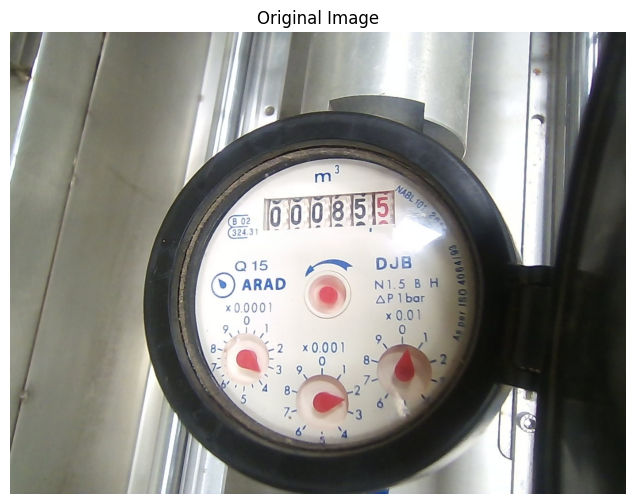

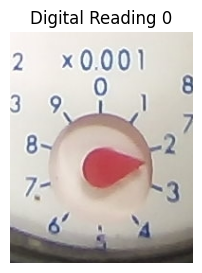

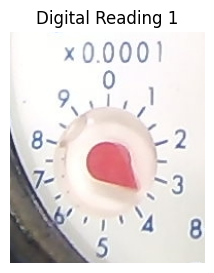

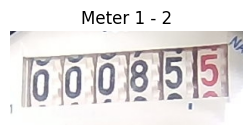

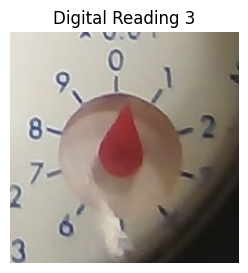

Done!


In [12]:
from ultralytics import YOLO
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tkinter import Tk
from tkinter.filedialog import askopenfilename

# -----------------------------
# LOAD YOLO MODEL
# -----------------------------
yolo_weights = "/home/akill-sud/Documents/projects/nagman_callibration/runs/detect/train8/weights/best.pt"
model = YOLO(yolo_weights)

# -----------------------------
# FILE UPLOAD DIALOG
# -----------------------------
Tk().withdraw()  # Hide main window
image_path = askopenfilename(title="Select an Image",
                             filetypes=[("Image Files", "*.jpg *.png *.jpeg")])

if not image_path:
    raise ValueError("No image selected!")

print("Selected file:", image_path)

# -----------------------------
# LOAD IMAGE
# -----------------------------
img = cv2.imread(image_path)

if img is None:
    raise ValueError("Failed to load image!")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# -----------------------------
# RUN YOLO
# -----------------------------
results = model(img)
print(f"Detected {len(results[0].boxes)} objects")

# -----------------------------
# SHOW ORIGINAL IMAGE
# -----------------------------
plt.figure(figsize=(8,6))
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

# -----------------------------
# SHOW CROPPED OBJECTS
# -----------------------------
for i, det in enumerate(results[0].boxes):
    x1, y1, x2, y2 = map(int, det.xyxy[0].cpu().numpy())
    label = int(det.cls.cpu().numpy().item())

    # Padding
    pad = 5
    x1p, y1p = max(0, x1 - pad), max(0, y1 - pad)
    x2p, y2p = min(img.shape[1], x2 + pad), min(img.shape[0], y2 + pad)

    roi = img[y1p:y2p, x1p:x2p]
    roi_rgb = cv2.cvtColor(roi, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(3,3))
    plt.imshow(roi_rgb)

    if label == 0:
        plt.title(f"Digital Reading {i}")
    else:
        plt.title(f"Meter {label} - {i}")

    plt.axis("off")
    plt.show()

print("Done!")

In [10]:
from ultralytics import YOLO
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tkinter import Tk
from tkinter.filedialog import askopenfilename
import imutils

# =========================
# CONFIG
# =========================
NUM_DIGITS = 6

# YOLO models
meter_model_path = "/home/akill-sud/Documents/projects/nagman_callibration/runs/detect/train8/weights/best.pt"
digit_model_path = "/home/akill-sud/Downloads/readings.yolov11/train/runs/detect/train3/weights/best.pt"

# =========================
# DEVICE
# =========================
if torch.cuda.is_available():
    device = 0
    print("✅ GPU:", torch.cuda.get_device_name(0))
else:
    device = "cpu"
    print("⚠️ Using CPU")

# =========================
# LOAD MODELS
# =========================
meter_model = YOLO(meter_model_path)
digit_model = YOLO(digit_model_path)

# =========================
# FILE UPLOAD
# =========================
Tk().withdraw()
image_path = askopenfilename(title="Select Meter Image",
                             filetypes=[("Image Files", "*.jpg *.png *.jpeg"))

if not image_path:
    raise ValueError("❌ No image selected!")

print("📂 Selected:", image_path)

# =========================
# LOAD IMAGE
# =========================
img = cv2.imread(image_path)

if img is None:
    raise ValueError("❌ Failed to load image!")

img = imutils.resize(img, width=800)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# =========================
# STEP 1: DETECT DIGITAL DISPLAY
# =========================
results = meter_model(img)

digital_roi = None

for det in results[0].boxes:
    label = int(det.cls.cpu().numpy().item())

    if label == 0:  # digital display
        x1, y1, x2, y2 = map(int, det.xyxy[0].cpu().numpy())

        # padding
        pad = 5
        x1, y1 = max(0, x1-pad), max(0, y1-pad)
        x2, y2 = min(img.shape[1], x2+pad), min(img.shape[0], y2+pad)

        digital_roi = img[y1:y2, x1:x2]
        break  # take first digital region

if digital_roi is None:
    raise ValueError("❌ No digital display detected!")

# =========================
# STEP 2: SPLIT DIGITS
# =========================
h, w = digital_roi.shape[:2]
digit_width = w // NUM_DIGITS

digits = []
for i in range(NUM_DIGITS):
    d = digital_roi[:, i*digit_width:(i+1)*digit_width]
    digits.append(d)

# =========================
# STEP 3: DIGIT PREDICTION
# =========================
names = digit_model.names
predicted_digits = []

for digit in digits:
    results = digit_model.predict(source=digit, conf=0.25, device=device, verbose=False)

    digit_value = "?"

    for r in results:
        if len(r.boxes) > 0:
            box = r.boxes[0]
            cls = int(box.cls[0])
            digit_value = names[cls]

    predicted_digits.append(digit_value)

# =========================
# STEP 4: FORMAT READING
# =========================
if len(predicted_digits) == 6:
    final_reading = "".join(predicted_digits[:5]) + "." + predicted_digits[5]
else:
    final_reading = "Invalid"

print("\n📟 Final Reading:", final_reading)

# =========================
# VISUALIZATION
# =========================
plt.figure(figsize=(16,6))

# Original
plt.subplot(2,4,1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis("off")

# Digital ROI
roi_rgb = cv2.cvtColor(digital_roi, cv2.COLOR_BGR2RGB)
plt.subplot(2,4,2)
plt.imshow(roi_rgb)
plt.title("Digital Display")
plt.axis("off")

# Digits
for i, digit in enumerate(digits):
    digit_rgb = cv2.cvtColor(digit, cv2.COLOR_BGR2RGB)

    plt.subplot(2, NUM_DIGITS, NUM_DIGITS + i + 1)
    plt.imshow(digit_rgb)
    plt.title(predicted_digits[i])
    plt.axis("off")

plt.suptitle(f"Meter Reading: {final_reading}", fontsize=16)
plt.tight_layout()
plt.show()

SyntaxError: closing parenthesis ')' does not match opening parenthesis '[' (2580825452.py, line 40)

Using: GPU
📂 Selected: /home/akill-sud/Documents/projects/nagman_callibration/dataset/captured_images_11/id_00004_1280x960.jpg

0: 480x640 3 meterss, 1 readings, 11.6ms
Speed: 3.0ms preprocess, 11.6ms inference, 1.6ms postprocess per image at shape (1, 3, 480, 640)
✅ Selected detection index: 2 (3rd object)

🔍 Predictions:

Digit 1: 0
Digit 2: 0
Digit 3: 0
Digit 4: 8
Digit 5: 5
Digit 6: 4

📟 Final Meter Reading: 00085.4


/tmp/ipykernel_6250/1337607549.py:174: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


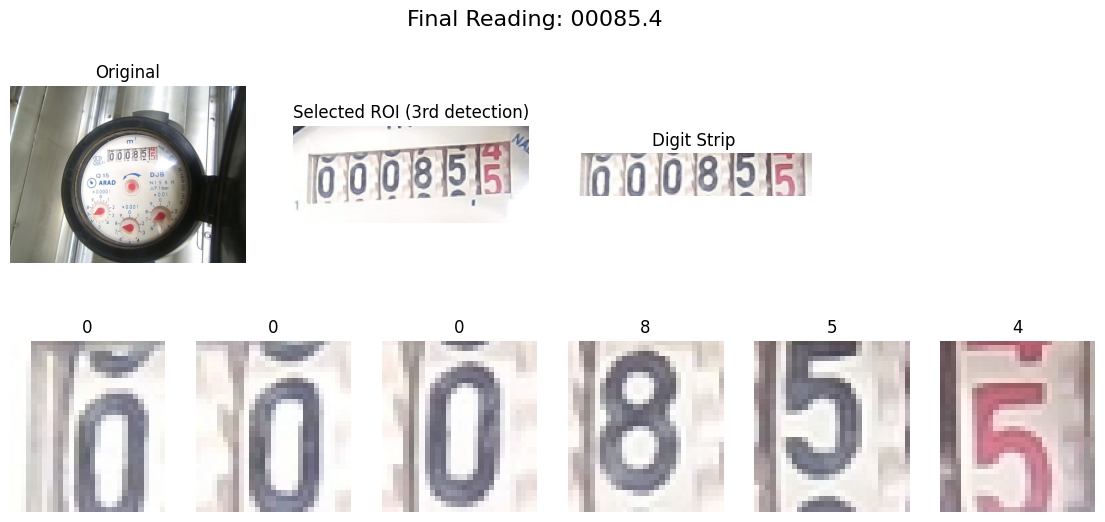

In [13]:
from ultralytics import YOLO
import torch
import cv2
import imutils
import numpy as np
import matplotlib.pyplot as plt
from tkinter import Tk
from tkinter.filedialog import askopenfilename

# =========================
# CONFIG
# =========================
NUM_DIGITS = 6
TARGET_INDEX = 2   # 👈 3rd detection

meter_model_path = "/home/akill-sud/Documents/projects/nagman_callibration/runs/detect/train8/weights/best.pt"
digit_model_path = "/home/akill-sud/Downloads/readings.yolov11/train/runs/detect/train3/weights/best.pt"

# =========================
# DEVICE
# =========================
device = 0 if torch.cuda.is_available() else "cpu"
print("Using:", "GPU" if device == 0 else "CPU")

# =========================
# LOAD MODELS
# =========================
meter_model = YOLO(meter_model_path)
digit_model = YOLO(digit_model_path)

# =========================
# FILE UPLOAD
# =========================
Tk().withdraw()
image_path = askopenfilename(
    title="Select Image",
    filetypes=[("Image Files", "*.jpg *.png *.jpeg")]
)

if not image_path:
    raise ValueError("❌ No image selected!")

print("📂 Selected:", image_path)

# =========================
# LOAD IMAGE
# =========================
img = cv2.imread(image_path)

if img is None:
    raise ValueError("❌ Failed to load image!")

img = imutils.resize(img, width=800)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# =========================
# STEP 1: DETECT OBJECTS
# =========================
results = meter_model(img)
boxes = results[0].boxes

if len(boxes) <= TARGET_INDEX:
    raise ValueError(f"❌ Need at least 3 detections, but found {len(boxes)}")

# 👉 PICK 3rd DETECTION
det = boxes[TARGET_INDEX]

x1, y1, x2, y2 = map(int, det.xyxy[0].cpu().numpy())

# Padding
pad = 5
x1, y1 = max(0, x1 - pad), max(0, y1 - pad)
x2, y2 = min(img.shape[1], x2 + pad), min(img.shape[0], y2 + pad)

roi = img[y1:y2, x1:x2]

print("✅ Selected detection index: 2 (3rd object)")

# =========================
# STEP 2: DIGIT STRIP
# =========================
def crop_digit_strip(image):
    h, w = image.shape[:2]
    return image[
        int(h * 0.30):int(h * 0.70),
        int(w * 0.05):int(w * 0.95)
    ]

digit_strip = crop_digit_strip(roi)

# =========================
# STEP 3: SPLIT DIGITS
# =========================
h, w = digit_strip.shape[:2]
digit_width = w // NUM_DIGITS

digits = []
for i in range(NUM_DIGITS):
    digit = digit_strip[:, i*digit_width:(i+1)*digit_width]
    digits.append(digit)

# =========================
# STEP 4: DIGIT PREDICTION
# =========================
names = digit_model.names
predicted_digits = []

print("\n🔍 Predictions:\n")

for i, digit in enumerate(digits):
    results = digit_model.predict(
        source=digit,
        conf=0.25,
        device=device,
        verbose=False
    )

    digit_value = "?"

    for r in results:
        if len(r.boxes) > 0:
            box = r.boxes[0]
            cls = int(box.cls[0])
            digit_value = names[cls]

    predicted_digits.append(digit_value)
    print(f"Digit {i+1}: {digit_value}")

# =========================
# STEP 5: FINAL READING
# =========================
if len(predicted_digits) == 6:
    final_reading = "".join(predicted_digits[:5]) + "." + predicted_digits[5]
else:
    final_reading = "Invalid"

print("\n📟 Final Meter Reading:", final_reading)

# =========================
# VISUALIZATION
# =========================
plt.figure(figsize=(14,6))

# Original
plt.subplot(2,4,1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis("off")

# ROI
roi_rgb = cv2.cvtColor(roi, cv2.COLOR_BGR2RGB)
plt.subplot(2,4,2)
plt.imshow(roi_rgb)
plt.title("Selected ROI (3rd detection)")
plt.axis("off")

# Digit strip
strip_rgb = cv2.cvtColor(digit_strip, cv2.COLOR_BGR2RGB)
plt.subplot(2,4,3)
plt.imshow(strip_rgb)
plt.title("Digit Strip")
plt.axis("off")

# Digits
for i, digit in enumerate(digits):
    digit_rgb = cv2.cvtColor(digit, cv2.COLOR_BGR2RGB)

    plt.subplot(2, NUM_DIGITS, NUM_DIGITS + i + 1)
    plt.imshow(digit_rgb)
    plt.title(predicted_digits[i])
    plt.axis("off")

plt.suptitle(f"Final Reading: {final_reading}", fontsize=16)
plt.tight_layout()
plt.show()

/home/akill-sud/anaconda3/envs/yolo_web/lib/python3.10/site-packages/google/api_core/_python_version_support.py:263: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
/home/akill-sud/anaconda3/envs/yolo_web/lib/python3.10/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.0.post2)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


✅ Classification model loaded
📂 Selected: /home/akill-sud/Documents/projects/yolo_web/predicted_images/id_2081.jpg

0: 480x640 3 meterss, 1 readings, 93.8ms
Speed: 5.8ms preprocess, 93.8ms inference, 22.4ms postprocess per image at shape (1, 3, 480, 640)
🔍 Total detections: 4
🎯 Using detections: [0, 2, 3]
💾 Saved: cropped_digits/digit_0.png
💾 Saved: cropped_digits/digit_2.png
💾 Saved: cropped_digits/digit_3.png
🔢 Digit 0: 9 (0.78)
🔢 Digit 2: 2 (0.96)
🔢 Digit 3: 2 (1.00)

📟 FINAL METER READING: 922



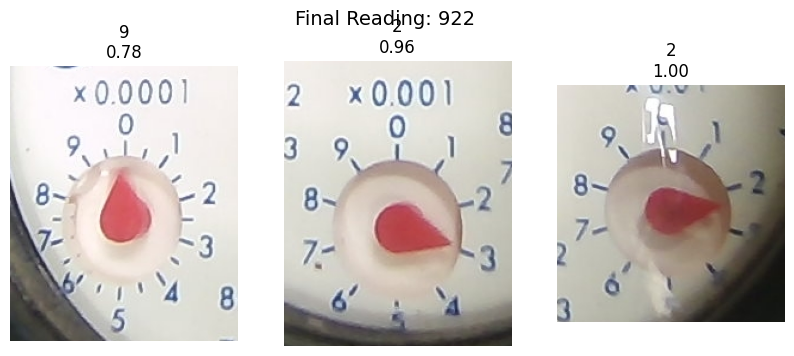

✅ PIPELINE COMPLETE


In [ ]:
# =========================================================
# 🔥 COMPLETE PIPELINE: YOLO → CROP → CLASSIFY → FINAL READING
# =========================================================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from tkinter import Tk
from tkinter.filedialog import askopenfilename

import tensorflow as tf
from tensorflow.keras.preprocessing import image

# =========================================================
# PARAMETERS
# =========================================================
YOLO_WEIGHTS = "/home/akill-sud/Documents/projects/nagman_callibration/runs/detect/train8/weights/best.pt"
MODEL_PATH = "/home/akill-sud/Documents/projects/yolo_web/rotary_inceptionresnet_best_model.keras"
METER_READINGS = ""


CROP_FOLDER = "cropped_digits"

# 🔥 KEEP TWO SIZES CLEAR
CLASSIFY_HEIGHT = 299
CLASSIFY_WIDTH = 299

# 👉 Choose which detections to use
SELECTED_INDICES = [0,2,3]

# =========================================================
# LOAD YOLO
# =========================================================
yolo_model = YOLO(YOLO_WEIGHTS)

# =========================================================
# LOAD CLASSIFICATION MODEL
# =========================================================
model = tf.keras.models.load_model(MODEL_PATH)
print("✅ Classification model loaded")

# =========================================================
# IMAGE UPLOAD
# =========================================================
Tk().withdraw()
image_path = askopenfilename(
    title="Select Meter Image",
    filetypes=[("Image Files", "*.jpg *.png *.jpeg")]
)

if not image_path:
    raise ValueError("No image selected!")

print("📂 Selected:", image_path)

# =========================================================
# LOAD IMAGE
# =========================================================
img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# =========================================================
# YOLO DETECTION
# =========================================================
results = yolo_model(img)

detections = results[0].boxes
print(f"🔍 Total detections: {len(detections)}")

# =========================================================
# SORT LEFT → RIGHT
# =========================================================
boxes = []
for i, det in enumerate(detections):
    x1, y1, x2, y2 = map(int, det.xyxy[0].cpu().numpy())
    boxes.append((i, x1, y1, x2, y2))

boxes = sorted(boxes, key=lambda x: x[1])

# =========================================================
# CREATE CROP FOLDER
# =========================================================
if os.path.exists(CROP_FOLDER):
    import shutil
    shutil.rmtree(CROP_FOLDER)

os.makedirs(CROP_FOLDER)

# =========================================================
# CROP ONLY SELECTED INDICES
# =========================================================
cropped_images = []

print(f"🎯 Using detections: {SELECTED_INDICES}")

for new_idx, (orig_idx, x1, y1, x2, y2) in enumerate(boxes):

    if new_idx not in SELECTED_INDICES:
        continue

    pad = 5
    x1p, y1p = max(0, x1 - pad), max(0, y1 - pad)
    x2p, y2p = min(img.shape[1], x2 + pad), min(img.shape[0], y2 + pad)

    roi = img[y1p:y2p, x1p:x2p]

    save_path = os.path.join(CROP_FOLDER, f"digit_{new_idx}.png")
    cv2.imwrite(save_path, roi)

    cropped_images.append((new_idx, save_path))

    print(f"💾 Saved: {save_path}")

# =========================================================
# PREDICT CROPPED IMAGES (🔥 FIX HERE ONLY)
# =========================================================
predictions = []

for idx, path in cropped_images:

    # 🔥 ALWAYS RESIZE TO MODEL EXPECTED SIZE
    img_pil = image.load_img(path, target_size=(CLASSIFY_HEIGHT, CLASSIFY_WIDTH))
    img_array = image.img_to_array(img_pil) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array, verbose=0)
    digit = np.argmax(pred)
    confidence = np.max(pred)

    predictions.append((idx, digit, confidence))

    print(f"🔢 Digit {idx}: {digit} ({confidence:.2f})")

# =========================================================
# SORT & FINAL READING
# =========================================================
predictions = sorted(predictions, key=lambda x: x[0])

final_reading = "".join([str(p[1]) for p in predictions])

print("\n=================================")
print(f"📟 FINAL METER READING: {final_reading}")
print("=================================\n")

# =========================================================
# DISPLAY RESULTS
# =========================================================
plt.figure(figsize=(10,4))

for i, (idx, digit, conf) in enumerate(predictions):
    img = cv2.imread(os.path.join(CROP_FOLDER, f"digit_{idx}.png"))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, len(predictions), i+1)
    plt.imshow(img)
    plt.title(f"{digit}\n{conf:.2f}")
    plt.axis("off")

plt.suptitle(f"Final Reading: {final_reading}", fontsize=14)
plt.show()

print("✅ PIPELINE COMPLETE")

Using: GPU
✅ All models loaded
📂 Selected: /home/akill-sud/Documents/projects/yolo_web/predicted_images/id_2081.jpg

0: 480x640 3 meterss, 1 readings, 11.3ms
Speed: 3.6ms preprocess, 11.3ms inference, 1.6ms postprocess per image at shape (1, 3, 480, 640)
🔍 Total detections: 4

🎯 Model 2 (Keras)
Keras Digit 0: 9
Keras Digit 2: 2
Keras Digit 3: 2

🎯 Model 3 (Digit YOLO)
Strip Digit 1: 0
Strip Digit 2: 0
Strip Digit 3: 0
Strip Digit 4: 9
Strip Digit 5: 0
Strip Digit 6: 8

📟 Model 3 Output : 00090.8
📟 Model 2 Output : 922
🚀 FINAL OUTPUT   : 00090.8922



/tmp/ipykernel_6211/2261398037.py:231: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


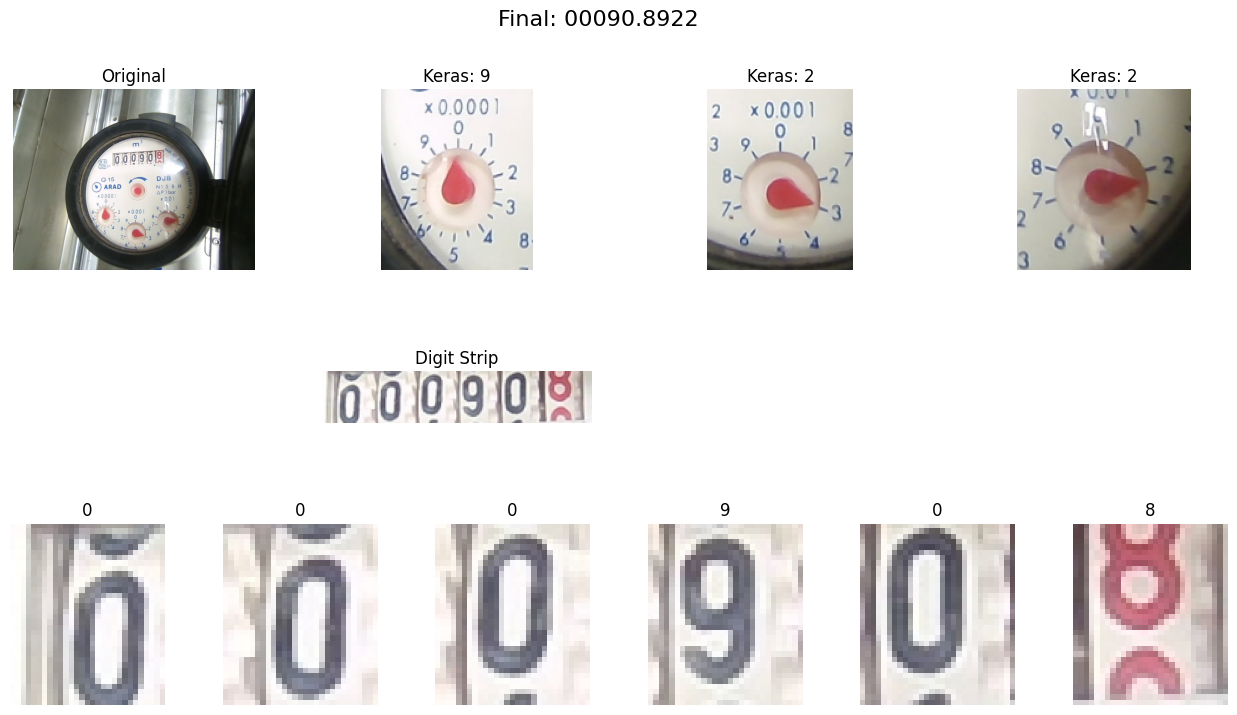

✅ PIPELINE COMPLETE


In [4]:
# =========================================================
# 🔥 COMPLETE PIPELINE:
# YOLO (Meter Detection) →
#   ├── Model 2 (Keras) → indices [0,2,3]
#   └── Model 3 (Digit YOLO) → index [1]
# FINAL → COMBINED OUTPUT
# =========================================================

import os
import cv2
import torch
import imutils
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from tkinter import Tk
from tkinter.filedialog import askopenfilename

import tensorflow as tf
from tensorflow.keras.preprocessing import image

# =========================================================
# CONFIG
# =========================================================
YOLO_METER_MODEL = "/home/akill-sud/Documents/projects/nagman_callibration/runs/detect/train8/weights/best.pt"
YOLO_DIGIT_MODEL = "/home/akill-sud/Downloads/readings.yolov11/train/runs/detect/train3/weights/best.pt"
KERAS_MODEL = "/home/akill-sud/Documents/projects/yolo_web/rotary_inceptionresnet_best_model.keras"

CROP_FOLDER = "cropped_digits"

KERAS_INDICES = [0, 2, 3]
STRIP_INDEX = 1

CLASSIFY_SIZE = 299
NUM_DIGITS = 6

# =========================================================
# DEVICE
# =========================================================
device = 0 if torch.cuda.is_available() else "cpu"
print("Using:", "GPU" if device == 0 else "CPU")

# =========================================================
# LOAD MODELS
# =========================================================
meter_model = YOLO(YOLO_METER_MODEL)
digit_model = YOLO(YOLO_DIGIT_MODEL)
classifier_model = tf.keras.models.load_model(KERAS_MODEL)

print("✅ All models loaded")

# =========================================================
# IMAGE INPUT
# =========================================================
Tk().withdraw()
image_path = askopenfilename(
    title="Select Meter Image",
    filetypes=[("Image Files", "*.jpg *.png *.jpeg")]
)

if not image_path:
    raise ValueError("No image selected!")

print("📂 Selected:", image_path)

# =========================================================
# LOAD IMAGE
# =========================================================
img = cv2.imread(image_path)
img = imutils.resize(img, width=800)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# =========================================================
# STEP 1: YOLO DETECTION
# =========================================================
results = meter_model(img)
detections = results[0].boxes

print(f"🔍 Total detections: {len(detections)}")

boxes = []
for i, det in enumerate(detections):
    x1, y1, x2, y2 = map(int, det.xyxy[0].cpu().numpy())
    boxes.append((i, x1, y1, x2, y2))

boxes = sorted(boxes, key=lambda x: x[1])

# =========================================================
# CREATE CROP FOLDER
# =========================================================
if os.path.exists(CROP_FOLDER):
    import shutil
    shutil.rmtree(CROP_FOLDER)

os.makedirs(CROP_FOLDER)

# =========================================================
# ================= MODEL 2 =================
# =========================================================
print("\n🎯 Model 2 (Keras)")

keras_preds = []
keras_images = []   # 🔥 NEW

for new_idx, (orig_idx, x1, y1, x2, y2) in enumerate(boxes):

    if new_idx not in KERAS_INDICES:
        continue

    pad = 5
    x1p, y1p = max(0, x1 - pad), max(0, y1 - pad)
    x2p, y2p = min(img.shape[1], x2 + pad), min(img.shape[0], y2 + pad)

    roi = img[y1p:y2p, x1p:x2p]

    save_path = os.path.join(CROP_FOLDER, f"digit_{new_idx}.png")
    cv2.imwrite(save_path, roi)

    keras_images.append((new_idx, roi))  # 🔥 STORE IMAGE

    img_pil = image.load_img(save_path, target_size=(CLASSIFY_SIZE, CLASSIFY_SIZE))
    img_array = image.img_to_array(img_pil) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = classifier_model.predict(img_array, verbose=0)
    digit = np.argmax(pred)

    keras_preds.append((new_idx, digit))
    print(f"Keras Digit {new_idx}: {digit}")

keras_preds = sorted(keras_preds, key=lambda x: x[0])
keras_reading = "".join([str(x[1]) for x in keras_preds])

# =========================================================
# ================= MODEL 3 =================
# =========================================================
print("\n🎯 Model 3 (Digit YOLO)")

if len(boxes) <= STRIP_INDEX:
    raise ValueError("❌ Not enough detections")

_, x1, y1, x2, y2 = boxes[STRIP_INDEX]

pad = 5
x1, y1 = max(0, x1 - pad), max(0, y1 - pad)
x2, y2 = min(img.shape[1], x2 + pad), min(img.shape[0], y2 + pad)

roi = img[y1:y2, x1:x2]

def crop_digit_strip(image):
    h, w = image.shape[:2]
    return image[int(h*0.30):int(h*0.70), int(w*0.05):int(w*0.95)]

digit_strip = crop_digit_strip(roi)

h, w = digit_strip.shape[:2]
digit_width = w // NUM_DIGITS

digits = []
for i in range(NUM_DIGITS):
    digits.append(digit_strip[:, i*digit_width:(i+1)*digit_width])

names = digit_model.names
strip_preds = []

for i, digit_img in enumerate(digits):
    results = digit_model.predict(source=digit_img, conf=0.25, device=device, verbose=False)

    digit_value = "?"
    for r in results:
        if len(r.boxes) > 0:
            cls = int(r.boxes[0].cls[0])
            digit_value = names[cls]

    strip_preds.append(digit_value)
    print(f"Strip Digit {i+1}: {digit_value}")

if len(strip_preds) == 6:
    strip_reading = "".join(strip_preds[:5]) + "." + strip_preds[5]
else:
    strip_reading = "Invalid"

# =========================================================
# FINAL OUTPUT
# =========================================================
final_output = f"{strip_reading}{keras_reading}"

print("\n=================================")
print(f"📟 Model 3 Output : {strip_reading}")
print(f"📟 Model 2 Output : {keras_reading}")
print(f"🚀 FINAL OUTPUT   : {final_output}")
print("=================================\n")

# =========================================================
# 🔥 VISUALIZATION (UPDATED)
# =========================================================
plt.figure(figsize=(16,8))

# Original
plt.subplot(3,4,1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis("off")

# 🔥 MODEL 2 VISUALS
for i, (idx, roi_img) in enumerate(keras_images):
    roi_rgb = cv2.cvtColor(roi_img, cv2.COLOR_BGR2RGB)
    pred_digit = [p[1] for p in keras_preds if p[0] == idx][0]

    plt.subplot(3,4,2+i)
    plt.imshow(roi_rgb)
    plt.title(f"Keras: {pred_digit}")
    plt.axis("off")

# Strip
strip_rgb = cv2.cvtColor(digit_strip, cv2.COLOR_BGR2RGB)
plt.subplot(3,4,6)
plt.imshow(strip_rgb)
plt.title("Digit Strip")
plt.axis("off")

# Digits
for i, digit in enumerate(digits):
    digit_rgb = cv2.cvtColor(digit, cv2.COLOR_BGR2RGB)
    plt.subplot(3, NUM_DIGITS, 2*NUM_DIGITS + i + 1)
    plt.imshow(digit_rgb)
    plt.title(strip_preds[i])
    plt.axis("off")

plt.suptitle(f"Final: {final_output}", fontsize=16)
plt.tight_layout()
plt.show()

print("✅ PIPELINE COMPLETE")